<a href="https://colab.research.google.com/github/PonchitoSalcedo/GPIA_Actividad_8/blob/main/GPIA_ACT8_monitoreo_produccion_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

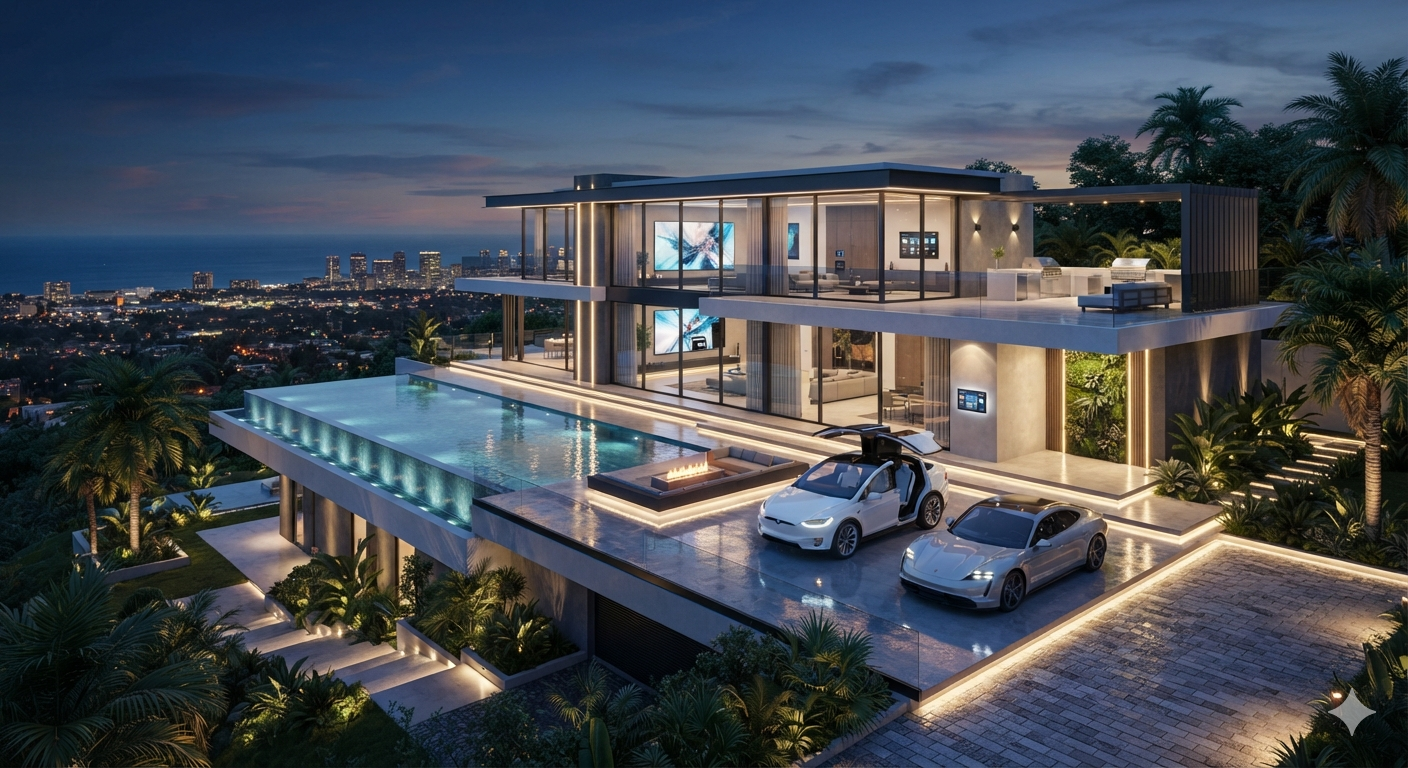

# Sistema de Monitorización Proactiva para Modelo en Producción
## Dataset: California Housing (regresión)

Este notebook implementa el **punto 4 (Código o configuración)** de la actividad:
scripts de monitoreo/automatización y configuración de alertas, sobre un enfoque
de observabilidad moderna (métricas, logs y trazas), usando el **California Housing
Dataset** incluido en scikit-learn como caso de uso (predicción del valor medio
de vivienda a partir de 8 features: ingreso medio, antigüedad, habitaciones, etc.).

Incluye:
- Seguimiento de desempeño con **MLflow** (RMSE, MAE, R²)
- Detección de **data drift** (PSI + prueba de Kolmogorov-Smirnov) sobre las 8 features
- **Alertas inteligentes** alineadas a SLOs y error budgets, con reducción de ruido
- **Simulación de escenarios de falla** (drift de distribución, incremento de latencia, degradación/concept drift)
- **Runbooks automatizados** (rollback, reentrenamiento, escalamiento)
- **Dashboard operativo** en tiempo real (simulado)

> Pensado para ejecutarse en Google Colab, celda por celda, de arriba hacia abajo.


## 1. Instalación de dependencias e imports

In [1]:
# scikit-learn, numpy, pandas, matplotlib y scipy ya vienen preinstalados en Colab.
# Solo necesitamos instalar MLflow.
!pip install mlflow -q

print("Verificando instalaciones...")
try:
    import mlflow
    print(f"   MLflow: {mlflow.__version__}")
except Exception as e:
    print("   MLflow no disponible:", e)


Verificando instalaciones...
   MLflow: 3.14.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import json, uuid, time, warnings
from datetime import datetime, timedelta, timezone
from collections import deque

import mlflow

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Librerías cargadas correctamente. MLflow versión:", mlflow.__version__)


Librerías cargadas correctamente. MLflow versión: 3.14.0


## 2. Configuración de MLflow (tracking de métricas, logs y trazas)

Usamos SQLite como backend de tracking (`sqlite:///mlflow.db`). Nota: las versiones
recientes de MLflow (3.x) dejaron el backend de archivos (`file:./mlruns`) en modo
mantenimiento, por eso usamos SQLite, que sí recibe soporte completo y no requiere
instalar nada adicional (viene incluido en Python).

Cada "paso" del monitoreo se registra como un *run* anidado dentro de un run padre,
lo que nos permite ver la evolución temporal del modelo en la UI de MLflow.


In [3]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
EXPERIMENTO = "monitoreo-produccion-california-housing"
mlflow.set_experiment(EXPERIMENTO)

print(f"Experimento activo: {EXPERIMENTO}")
print("Para visualizar el dashboard de MLflow en Colab, ejecuta en otra celda:")
print("  !mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000 &")


2026/07/20 04:45:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/20 04:45:07 INFO mlflow.store.db.utils: Updating database tables
2026/07/20 04:45:11 INFO mlflow.tracking.fluent: Experiment with name 'monitoreo-produccion-california-housing' does not exist. Creating a new experiment.


Experimento activo: monitoreo-produccion-california-housing
Para visualizar el dashboard de MLflow en Colab, ejecuta en otra celda:
  !mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000 &


## 3. Modelo base en "producción": California Housing

Cargamos el dataset (regresión: predecir `MedHouseVal`, el valor medio de vivienda
en cientos de miles de dólares, a partir de 8 features: `MedInc`, `HouseAge`,
`AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`).

Dividimos los datos en tres partes:
- **`X_fit` / `y_fit`**: para entrenar el modelo "ya desplegado".
- **`X_hold` / `y_hold`**: un holdout usado únicamente para **calibrar los SLOs**
  de forma realista (basados en el desempeño real de validación, no en el
  entrenamiento, que estaría sesgado).
- **`X_stream` / `y_stream`**: el "pool" de datos del que simulamos que llega
  tráfico de producción, lote a lote, durante el monitoreo.


In [4]:
datos = fetch_california_housing(as_frame=True)
feature_names = datos.feature_names
X_todo = datos.data.values
y_todo = datos.target.values

print("Features:", feature_names)
print("Shape total:", X_todo.shape)

# Partición: 60% para entrenar/calibrar el modelo, 40% como "pool" de producción a monitorear
X_train, X_stream, y_train, y_stream = train_test_split(X_todo, y_todo, test_size=0.4, random_state=42)
X_fit, X_hold, y_fit, y_hold = train_test_split(X_train, y_train, test_size=0.2, random_state=7)

modelo = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
modelo.fit(X_fit, y_fit)

X_ref = X_fit  # muestra de referencia para detección de drift

pred_hold = modelo.predict(X_hold)
rmse_hold = mean_squared_error(y_hold, pred_hold) ** 0.5
mae_hold = mean_absolute_error(y_hold, pred_hold)
r2_hold = r2_score(y_hold, pred_hold)

print(f"Desempeño en holdout -> RMSE: {rmse_hold:.3f} | MAE: {mae_hold:.3f} | R²: {r2_hold:.3f}")


Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape total: (20640, 8)
Desempeño en holdout -> RMSE: 0.536 | MAE: 0.365 | R²: 0.776


## 4. Definición de indicadores: SLOs y Error Budget

Los SLOs de regresión se **calibran dinámicamente a partir del desempeño en el
holdout** (buena práctica de MLOps: el objetivo de servicio debe basarse en lo
que el modelo realmente puede lograr en datos no vistos, con un margen de tolerancia,
no en un número arbitrario fijo).

- **RMSE máximo aceptable** = 1.3x el RMSE de holdout
- **MAE máximo aceptable** = 1.3x el MAE de holdout
- **R² mínimo aceptable** = R² de holdout − 0.15
- **Umbral de drift (PSI)** = 2.0 (valor fijo, ver sección 6)

El **error budget** se calcula sobre una ventana móvil de predicciones individuales:
una predicción se considera "exitosa" si su error absoluto está por debajo de
`1.5x MAE de holdout` (tolerancia calibrada). El presupuesto de error restante es
el % del margen de fallas permitido (según el SLO de tasa de éxito) que aún no
se ha consumido.


In [5]:
SLOS = {
    "rmse_max": round(rmse_hold * 1.3, 3),
    "mae_max": round(mae_hold * 1.3, 3),
    "r2_min": round(max(0.0, r2_hold - 0.15), 3),
    "drift_psi_max": 2.0,
}
TOLERANCIA_ERROR_INDIVIDUAL = mae_hold * 1.5
TASA_EXITO_OBJETIVO = 0.75  # SLO: % de predicciones individuales dentro de tolerancia

class ErrorBudget:
    """Calcula el presupuesto de error restante sobre una ventana móvil de resultados."""
    def __init__(self, slo_target, ventana=30):
        self.slo_target = slo_target
        self.ventana = deque(maxlen=ventana)

    def actualizar(self, exito: bool):
        self.ventana.append(1 if exito else 0)

    @property
    def tasa_observada(self):
        return sum(self.ventana) / len(self.ventana) if self.ventana else 1.0

    @property
    def presupuesto_restante_pct(self):
        falla_permitida = 1 - self.slo_target
        falla_observada = 1 - self.tasa_observada
        if falla_permitida <= 0:
            return 0.0
        restante = 1 - (falla_observada / falla_permitida)
        return max(0.0, min(1.0, restante)) * 100

error_budget = ErrorBudget(slo_target=TASA_EXITO_OBJETIVO, ventana=30)

print("SLOs calibrados dinámicamente:", SLOS)
print(f"Tolerancia de error individual: {TOLERANCIA_ERROR_INDIVIDUAL:.3f}")


SLOs calibrados dinámicamente: {'rmse_max': 0.697, 'mae_max': 0.475, 'r2_min': 0.626, 'drift_psi_max': 2.0}
Tolerancia de error individual: 0.548


## 5. Observabilidad: métricas, logs y trazas

- **Métricas**: se registran en MLflow (`mlflow.log_metrics`) para poder graficar tendencias.
- **Logs**: eventos estructurados en formato JSON (nivel, mensaje, contexto) — simulan lo que
  en producción real iría a un sistema como CloudWatch, Loki o Datadog.
- **Trazas**: cada lote procesado genera un `trace_id` único con su duración,
  simulando una traza distribuida de principio a fin.


In [6]:
logs_estructurados = []
trazas = []

def registrar_log(nivel, mensaje, contexto=None):
    entrada = {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "nivel": nivel,
        "mensaje": mensaje,
        "contexto": contexto or {},
    }
    logs_estructurados.append(entrada)
    print(f"[{entrada['timestamp']}] [{nivel.upper()}] {mensaje}")
    return entrada

def registrar_traza(nombre_operacion, duracion_ms, metadatos=None):
    traza = {
        "trace_id": str(uuid.uuid4())[:12],
        "operacion": nombre_operacion,
        "duracion_ms": round(duracion_ms, 2),
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "metadatos": metadatos or {},
    }
    trazas.append(traza)
    return traza

registrar_log("info", "Sistema de observabilidad inicializado", {"experimento": EXPERIMENTO, "features": feature_names})


[2026-07-20T04:45:46.994217+00:00] [INFO] Sistema de observabilidad inicializado


{'timestamp': '2026-07-20T04:45:46.994217+00:00',
 'nivel': 'info',
 'mensaje': 'Sistema de observabilidad inicializado',
 'contexto': {'experimento': 'monitoreo-produccion-california-housing',
  'features': ['MedInc',
   'HouseAge',
   'AveRooms',
   'AveBedrms',
   'Population',
   'AveOccup',
   'Latitude',
   'Longitude']}}

## 6. Detección de data drift (PSI + Kolmogorov-Smirnov)

Comparamos la distribución de cada una de las 8 features en el lote actual contra
la distribución de referencia (`X_ref`, tomada del set de entrenamiento) usando dos
técnicas complementarias:

- **PSI (Population Stability Index)**: mide qué tan distinta es la distribución actual
  de la de referencia. Como referencia general: PSI < 0.1 sin cambio relevante,
  0.1–0.25 cambio moderado, > 0.25 cambio significativo (aquí usamos un umbral
  ajustado a la escala del ejemplo, ver `SLOS["drift_psi_max"]`).
- **Prueba KS**: valida estadísticamente si dos muestras provienen de la misma distribución.


In [7]:
def calcular_psi(referencia, actual, buckets=10):
    puntos_corte = np.percentile(referencia, np.linspace(0, 100, buckets + 1))
    puntos_corte[0], puntos_corte[-1] = -np.inf, np.inf
    ref_counts, _ = np.histogram(referencia, bins=puntos_corte)
    cur_counts, _ = np.histogram(actual, bins=puntos_corte)
    ref_pct = np.clip(ref_counts / ref_counts.sum(), 1e-6, None)
    cur_pct = np.clip(cur_counts / cur_counts.sum(), 1e-6, None)
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))

def detectar_drift(X_actual):
    """Devuelve el PSI máximo entre features y el detalle por feature."""
    detalle = []
    for i, nombre in enumerate(feature_names):
        psi_f = calcular_psi(X_ref[:, i], X_actual[:, i])
        ks_p = stats.ks_2samp(X_ref[:, i], X_actual[:, i]).pvalue
        detalle.append({"feature": nombre, "psi": psi_f, "ks_p_value": ks_p})
    psi_max = max(d["psi"] for d in detalle)
    return psi_max, detalle


## 7. Motor de alertas inteligentes (con reducción de ruido)

El `AlertManager` evalúa condiciones de negocio (SLOs/error budget) y técnicas
(drift/latencia), asigna una **severidad** según el impacto operativo, y aplica
un **cooldown** por tipo de alerta para evitar *alert fatigue* (no repetir la
misma alerta en cada paso si la condición persiste).


In [8]:
class AlertManager:
    def __init__(self, cooldown_segundos=30):
        self.cooldown = timedelta(seconds=cooldown_segundos)
        self.ultimo_disparo = {}
        self.historial = []

    def evaluar(self, nombre, condicion, severidad, mensaje, ahora=None):
        ahora = ahora or datetime.now(timezone.utc)
        if not condicion:
            return None
        anterior = self.ultimo_disparo.get(nombre)
        if anterior and (ahora - anterior) < self.cooldown:
            return None  # deduplicación: misma alerta activa reciente, se omite ruido
        self.ultimo_disparo[nombre] = ahora
        alerta = {
            "id": str(uuid.uuid4())[:8],
            "name": nombre,
            "severity": severidad,   # critical | warning | info
            "message": mensaje,
            "timestamp": ahora.isoformat(),
        }
        self.historial.append(alerta)
        return alerta

alert_manager = AlertManager(cooldown_segundos=0)  # 0 = sin cooldown para ver todos los eventos en esta demo


## 8. Runbooks de respuesta automatizada

Ante cada tipo de alerta, el `RunbookEngine` dispara la acción correctiva
correspondiente: rollback a una versión anterior del modelo, disparo de
reentrenamiento, escalamiento de infraestructura o notificación al equipo on-call.


In [9]:
class RunbookEngine:
    def __init__(self):
        self.log_ejecucion = []

    def _registrar(self, nombre, detalle, resultado):
        entrada = {"runbook": nombre, "detalle": detalle, "resultado": resultado,
                   "timestamp": datetime.now(timezone.utc).isoformat()}
        self.log_ejecucion.append(entrada)
        registrar_log("warning", f"Runbook ejecutado: {nombre}", entrada)
        return entrada

    def rollback_modelo(self, version_actual="v3", version_anterior="v2"):
        return self._registrar("rollback_modelo",
                                f"Revirtiendo despliegue de {version_actual} a {version_anterior}",
                                "ejecutado")

    def reentrenamiento_automatico(self, motivo):
        return self._registrar("reentrenamiento_automatico",
                                f"Disparando pipeline de reentrenamiento. Motivo: {motivo}",
                                "encolado")

    def escalamiento_infraestructura(self, motivo):
        return self._registrar("escalamiento_infraestructura",
                                f"Escalando réplicas del servicio. Motivo: {motivo}",
                                "ejecutado")

    def notificar_equipo_guardia(self, alerta):
        return self._registrar("notificar_equipo_guardia",
                                f"Notificando on-call: {alerta['message']}",
                                "enviado")

    def despachar(self, alerta):
        nombre = alerta["name"]
        if nombre == "data_drift":
            self.reentrenamiento_automatico(motivo="data drift detectado en features de entrada")
            self.notificar_equipo_guardia(alerta)
        elif nombre in ("rmse_degradation", "mae_degradation", "r2_degradation"):
            self.rollback_modelo()
            self.notificar_equipo_guardia(alerta)
        elif nombre == "latency_spike":
            self.escalamiento_infraestructura(motivo="incremento de latencia p95")
        elif nombre == "error_budget_exhausted":
            self.rollback_modelo()
            self.notificar_equipo_guardia(alerta)
        else:
            self.notificar_equipo_guardia(alerta)

runbook_engine = RunbookEngine()


## 9. Simulador de escenarios de falla

Definimos en qué "pasos" de la simulación se inyectan fallas, usando el dataset
de California Housing como base:

- **Pasos 5-6**: pico de latencia (ej. sobrecarga del servicio).
- **Pasos 8 en adelante**: **data drift** — se simula la llegada de datos de zonas
  con ingreso medio (`MedInc`) y ocupación promedio (`AveOccup`) mucho más altos
  de lo normal (ej. el servicio empieza a recibir tráfico de una región nueva
  no representada en el entrenamiento).
- **Pasos 11 en adelante**: **degradación / concept drift** — se le agrega ruido
  fuerte a la relación real features→precio (ej. una caída del mercado inmobiliario
  que cambia por completo cómo se relacionan las features con el valor de la vivienda,
  algo que el modelo entrenado no puede anticipar).


In [10]:
N_STEPS = 16
LATENCIA_BASE_MS = 50
IDX_MEDINC = feature_names.index("MedInc")
IDX_AVEOCCUP = feature_names.index("AveOccup")

def escenario_de_falla(step):
    return {
        "drift": step >= 8,
        "latencia_extra": 150 if step in (5, 6) else 0,
        "degradar": step >= 11,
    }

def generar_batch(n_muestras, drift=False, degradar=False, seed=None):
    """Simula un lote de tráfico de producción muestreando del pool `X_stream`/`y_stream`."""
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(X_stream), size=n_muestras)
    Xb = X_stream[idx].copy()
    yb = y_stream[idx].copy()
    if drift:
        # Simula una nueva región con ingreso medio y ocupación promedio mucho más altos
        Xb[:, IDX_MEDINC] = Xb[:, IDX_MEDINC] * 1.6 + 3.0
        Xb[:, IDX_AVEOCCUP] = Xb[:, IDX_AVEOCCUP] * 1.4 + 2.0
    if degradar:
        # Simula concept drift: la relación features->precio deja de sostenerse
        yb = yb + rng.normal(scale=2.0 * y_fit.std(), size=n_muestras)
    return Xb, yb


## 10. Loop principal de monitoreo (tiempo real simulado)

Por cada paso: se genera tráfico simulado, se predice, se miden métricas de
regresión (RMSE, MAE, R², latencia, drift), se registran en MLflow y en los
logs/trazas, se actualiza el error budget, se evalúan las alertas y, si
corresponde, se disparan los runbooks automáticamente.


In [11]:
historial = {"step": [], "rmse": [], "mae": [], "r2": [], "latency_ms": [], "drift_psi": [], "budget_pct": []}

with mlflow.start_run(run_name="monitoreo_run_padre") as run_padre:
    mlflow.log_params({**SLOS, "n_steps": N_STEPS, "tasa_exito_objetivo": TASA_EXITO_OBJETIVO,
                        "tolerancia_error_individual": TOLERANCIA_ERROR_INDIVIDUAL})

    for step in range(N_STEPS):
        falla = escenario_de_falla(step)
        X_batch, y_batch = generar_batch(80, drift=falla["drift"], degradar=falla["degradar"], seed=200 + step)

        t0 = time.perf_counter()
        y_pred = modelo.predict(X_batch)
        latencia_ms = (time.perf_counter() - t0) * 1000 + LATENCIA_BASE_MS + falla["latencia_extra"]

        rmse = mean_squared_error(y_batch, y_pred) ** 0.5
        mae = mean_absolute_error(y_batch, y_pred)
        r2 = r2_score(y_batch, y_pred)

        for error_abs in np.abs(y_batch - y_pred):
            error_budget.actualizar(error_abs < TOLERANCIA_ERROR_INDIVIDUAL)

        psi_max, detalle_drift = detectar_drift(X_batch)
        budget_pct = error_budget.presupuesto_restante_pct

        # -- Métricas y trazas --
        with mlflow.start_run(run_name=f"step_{step}", nested=True):
            mlflow.log_metrics({
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "latency_ms": latencia_ms,
                "drift_psi_max": psi_max,
                "error_budget_pct": budget_pct,
            }, step=step)
        registrar_traza("procesar_lote", latencia_ms, {"step": step, "n_registros": len(X_batch)})

        historial["step"].append(step)
        historial["rmse"].append(rmse)
        historial["mae"].append(mae)
        historial["r2"].append(r2)
        historial["latency_ms"].append(latencia_ms)
        historial["drift_psi"].append(psi_max)
        historial["budget_pct"].append(budget_pct)

        # -- Alertas inteligentes alineadas a SLOs/error budget, priorizadas por impacto --
        a1 = alert_manager.evaluar("data_drift", psi_max > SLOS["drift_psi_max"], "warning",
                                    f"Drift detectado (PSI máx={psi_max:.2f}) en el paso {step}")
        a2 = alert_manager.evaluar("latency_spike", latencia_ms > 150, "warning",
                                    f"Latencia {latencia_ms:.0f}ms supera el umbral operativo en el paso {step}")
        a3 = alert_manager.evaluar("rmse_degradation", rmse > SLOS["rmse_max"], "critical",
                                    f"RMSE {rmse:.2f} supera el SLO ({SLOS['rmse_max']:.2f}) en el paso {step}")
        a4 = alert_manager.evaluar("r2_degradation", r2 < SLOS["r2_min"], "critical",
                                    f"R² {r2:.2f} cae por debajo del SLO ({SLOS['r2_min']:.2f}) en el paso {step}")
        a5 = alert_manager.evaluar("error_budget_exhausted", budget_pct <= 0, "critical",
                                    f"Error budget agotado en el paso {step}")

        for alerta in (a1, a2, a3, a4, a5):
            if alerta:
                registrar_log(alerta["severity"], f"ALERTA[{alerta['severity']}] {alerta['message']}", alerta)
                if alerta["severity"] == "critical" or alerta["name"] == "data_drift":
                    runbook_engine.despachar(alerta)

print("\nSimulación completa.")
print(f"Total de alertas generadas: {len(alert_manager.historial)}")
print(f"Total de runbooks ejecutados: {len(runbook_engine.log_ejecucion)}")


[2026-07-20T04:45:58.727250+00:00] [CRITICAL] ALERTA[critical] Error budget agotado en el paso 2
[2026-07-20T04:45:58.727390+00:00] [WARNING] Runbook ejecutado: rollback_modelo
[2026-07-20T04:45:58.727417+00:00] [WARNING] Runbook ejecutado: notificar_equipo_guardia
[2026-07-20T04:45:58.885613+00:00] [CRITICAL] ALERTA[critical] Error budget agotado en el paso 3
[2026-07-20T04:45:58.885677+00:00] [WARNING] Runbook ejecutado: rollback_modelo
[2026-07-20T04:45:58.885701+00:00] [WARNING] Runbook ejecutado: notificar_equipo_guardia
[2026-07-20T04:45:59.154252+00:00] [WARNING] ALERTA[warning] Latencia 235ms supera el umbral operativo en el paso 5
[2026-07-20T04:45:59.290548+00:00] [WARNING] ALERTA[warning] Latencia 239ms supera el umbral operativo en el paso 6
[2026-07-20T04:45:59.570634+00:00] [WARNING] ALERTA[warning] Drift detectado (PSI máx=12.43) en el paso 8
[2026-07-20T04:45:59.570784+00:00] [WARNING] Runbook ejecutado: reentrenamiento_automatico
[2026-07-20T04:45:59.570812+00:00] [WAR

## 11. Dashboard operativo en tiempo real (simulado)

Visualizamos la evolución de las métricas clave (RMSE, MAE/R², drift, error budget)
y marcamos con líneas verticales los pasos donde se dispararon alertas críticas,
para apoyar la toma de decisiones.


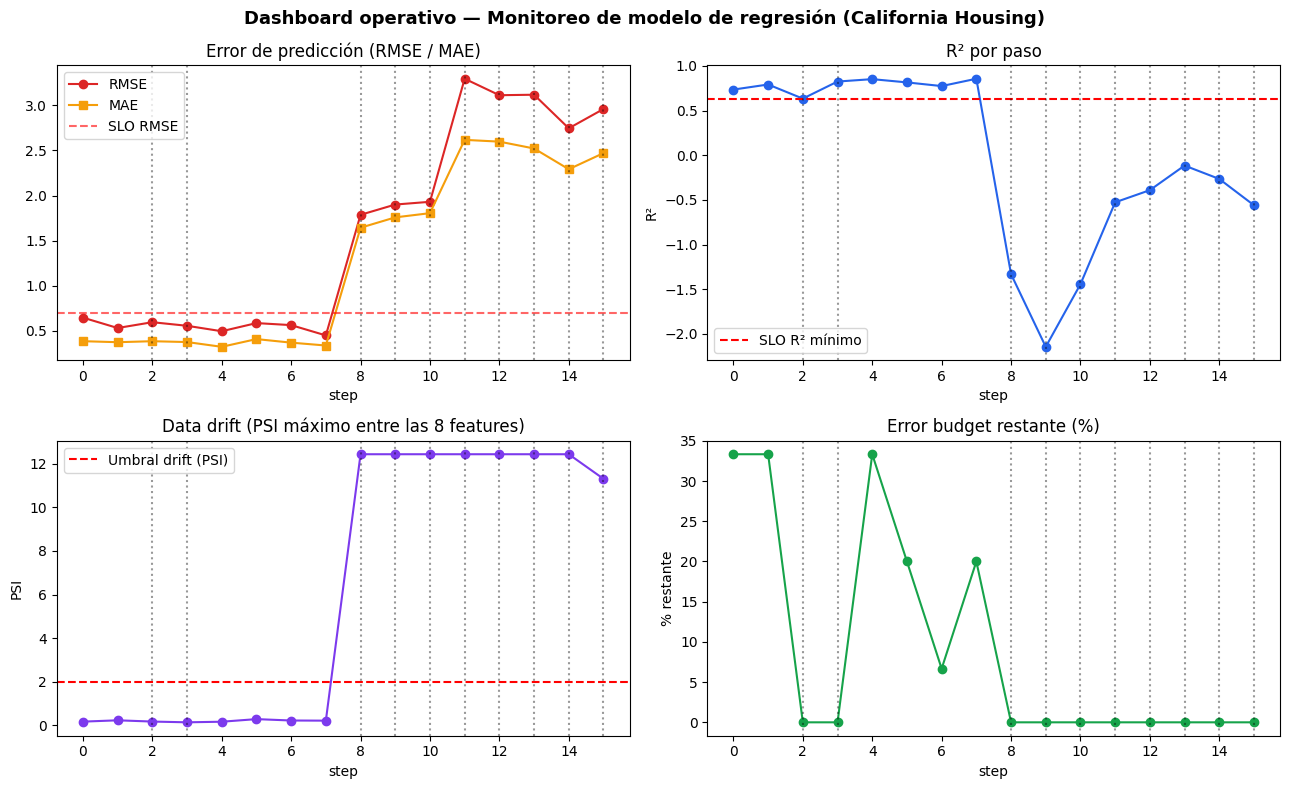

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Dashboard operativo — Monitoreo de modelo de regresión (California Housing)", fontsize=13, fontweight="bold")

pasos_criticos = sorted({int(a["message"].split("paso ")[-1]) for a in alert_manager.historial
                          if a["severity"] == "critical" and "paso" in a["message"]})

ax = axes[0,0]
ax.plot(historial["step"], historial["rmse"], marker="o", color="#dc2626", label="RMSE")
ax.plot(historial["step"], historial["mae"], marker="s", color="#f59e0b", label="MAE")
ax.axhline(SLOS["rmse_max"], color="red", linestyle="--", alpha=0.6, label="SLO RMSE")
ax.set_title("Error de predicción (RMSE / MAE)"); ax.set_xlabel("step"); ax.legend()

ax = axes[0,1]
ax.plot(historial["step"], historial["r2"], marker="o", color="#2563eb")
ax.axhline(SLOS["r2_min"], color="red", linestyle="--", label="SLO R² mínimo")
ax.set_title("R² por paso"); ax.set_xlabel("step"); ax.set_ylabel("R²"); ax.legend()

ax = axes[1,0]
ax.plot(historial["step"], historial["drift_psi"], marker="o", color="#7c3aed")
ax.axhline(SLOS["drift_psi_max"], color="red", linestyle="--", label="Umbral drift (PSI)")
ax.set_title("Data drift (PSI máximo entre las 8 features)"); ax.set_xlabel("step"); ax.set_ylabel("PSI"); ax.legend()

ax = axes[1,1]
ax.plot(historial["step"], historial["budget_pct"], marker="o", color="#16a34a")
ax.set_title("Error budget restante (%)"); ax.set_xlabel("step"); ax.set_ylabel("% restante")

for ax in axes.flat:
    for pc in pasos_criticos:
        ax.axvline(pc, color="black", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()


## 12. Resumen de incidentes y runbooks ejecutados

Tabla consolidada de todas las alertas disparadas y las acciones correctivas
automáticas asociadas, útil como evidencia para el documento técnico (punto 1)
y como insumo para los runbooks documentados (punto 3).


In [13]:
df_alertas = pd.DataFrame(alert_manager.historial)
df_runbooks = pd.DataFrame(runbook_engine.log_ejecucion)

print("=== Alertas disparadas ===")
display(df_alertas)

print("\n=== Runbooks ejecutados automáticamente ===")
display(df_runbooks)

print("\n=== Últimos logs estructurados (JSON) ===")
for log in logs_estructurados[-5:]:
    print(json.dumps(log, indent=2, ensure_ascii=False))


=== Alertas disparadas ===


,id,name,severity,message,timestamp
0,e9dd4fdd,error_budget_exhausted,critical,Error budget agotado en el paso 2,2026-07-20T04:45:58.727209+00:00
1,d852b898,error_budget_exhausted,critical,Error budget agotado en el paso 3,2026-07-20T04:45:58.885574+00:00
2,5318d1c7,latency_spike,warning,Latencia 235ms supera el umbral operativo en e...,2026-07-20T04:45:59.154214+00:00
3,280f39a1,latency_spike,warning,Latencia 239ms supera el umbral operativo en e...,2026-07-20T04:45:59.290504+00:00
4,112ae5c1,data_drift,warning,Drift detectado (PSI máx=12.43) en el paso 8,2026-07-20T04:45:59.570539+00:00
5,dccb0424,rmse_degradation,critical,RMSE 1.79 supera el SLO (0.70) en el paso 8,2026-07-20T04:45:59.570574+00:00
6,4ffa6500,r2_degradation,critical,R² -1.33 cae por debajo del SLO (0.63) en el p...,2026-07-20T04:45:59.570595+00:00
7,02b02bf1,error_budget_exhausted,critical,Error budget agotado en el paso 8,2026-07-20T04:45:59.570613+00:00
8,4883add0,data_drift,warning,Drift detectado (PSI máx=12.43) en el paso 9,2026-07-20T04:45:59.714337+00:00
9,8778d746,rmse_degradation,critical,RMSE 1.90 supera el SLO (0.70) en el paso 9,2026-07-20T04:45:59.714375+00:00



=== Runbooks ejecutados automáticamente ===


,runbook,detalle,resultado,timestamp
0,rollback_modelo,Revirtiendo despliegue de v3 a v2,ejecutado,2026-07-20T04:45:58.727377+00:00
1,notificar_equipo_guardia,Notificando on-call: Error budget agotado en e...,enviado,2026-07-20T04:45:58.727409+00:00
2,rollback_modelo,Revirtiendo despliegue de v3 a v2,ejecutado,2026-07-20T04:45:58.885668+00:00
3,notificar_equipo_guardia,Notificando on-call: Error budget agotado en e...,enviado,2026-07-20T04:45:58.885695+00:00
4,reentrenamiento_automatico,Disparando pipeline de reentrenamiento. Motivo...,encolado,2026-07-20T04:45:59.570772+00:00
...,...,...,...,...
63,notificar_equipo_guardia,Notificando on-call: RMSE 2.96 supera el SLO (...,enviado,2026-07-20T04:46:00.659041+00:00
64,rollback_modelo,Revirtiendo despliegue de v3 a v2,ejecutado,2026-07-20T04:46:00.659073+00:00
65,notificar_equipo_guardia,Notificando on-call: R² -0.56 cae por debajo d...,enviado,2026-07-20T04:46:00.659092+00:00
66,rollback_modelo,Revirtiendo despliegue de v3 a v2,ejecutado,2026-07-20T04:46:00.659121+00:00



=== Últimos logs estructurados (JSON) ===
{
  "timestamp": "2026-07-20T04:46:00.659080+00:00",
  "nivel": "warning",
  "mensaje": "Runbook ejecutado: rollback_modelo",
  "contexto": {
    "runbook": "rollback_modelo",
    "detalle": "Revirtiendo despliegue de v3 a v2",
    "resultado": "ejecutado",
    "timestamp": "2026-07-20T04:46:00.659073+00:00"
  }
}
{
  "timestamp": "2026-07-20T04:46:00.659097+00:00",
  "nivel": "warning",
  "mensaje": "Runbook ejecutado: notificar_equipo_guardia",
  "contexto": {
    "runbook": "notificar_equipo_guardia",
    "detalle": "Notificando on-call: R² -0.56 cae por debajo del SLO (0.63) en el paso 15",
    "resultado": "enviado",
    "timestamp": "2026-07-20T04:46:00.659092+00:00"
  }
}
{
  "timestamp": "2026-07-20T04:46:00.659110+00:00",
  "nivel": "critical",
  "mensaje": "ALERTA[critical] Error budget agotado en el paso 15",
  "contexto": {
    "id": "a7f7b418",
    "name": "error_budget_exhausted",
    "severity": "critical",
    "message": "Error

In [14]:
df_runbooks.to_csv('runbooks_ejecutados.csv', index=False)
print('El archivo runbooks_ejecutados.csv ha sido guardado.')

El archivo runbooks_ejecutados.csv ha sido guardado.


**Generar LOG.JASON**

In [15]:
with open('log.json', 'w', encoding='utf-8') as f:
    json.dump(logs_estructurados, f, ensure_ascii=False, indent=2)
print('El archivo log.json ha sido creado exitosamente.')

El archivo log.json ha sido creado exitosamente.


**Tabla log**

In [16]:
df_logs_from_file = pd.read_json('log.json')
display(df_logs_from_file.head())

,timestamp,nivel,mensaje,contexto
0,2026-07-20 04:45:46.994217+00:00,info,Sistema de observabilidad inicializado,{'experimento': 'monitoreo-produccion-californ...
1,2026-07-20 04:45:58.727250+00:00,critical,ALERTA[critical] Error budget agotado en el pa...,"{'id': 'e9dd4fdd', 'name': 'error_budget_exhau..."
2,2026-07-20 04:45:58.727390+00:00,warning,Runbook ejecutado: rollback_modelo,"{'runbook': 'rollback_modelo', 'detalle': 'Rev..."
3,2026-07-20 04:45:58.727417+00:00,warning,Runbook ejecutado: notificar_equipo_guardia,"{'runbook': 'notificar_equipo_guardia', 'detal..."
4,2026-07-20 04:45:58.885613+00:00,critical,ALERTA[critical] Error budget agotado en el pa...,"{'id': 'd852b898', 'name': 'error_budget_exhau..."


In [17]:
df_logs_from_file.to_csv('log.csv', index=False)
print('El archivo log.csv ha sido guardado exitosamente.')

El archivo log.csv ha sido guardado exitosamente.


## 13. (Opcional) Explorar resultados en la UI de MLflow

Para inspeccionar visualmente todas las métricas registradas por MLflow dentro
de Colab, puedes ejecutar lo siguiente en una celda nueva:

```python
!mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000 &
from pyngrok import ngrok
public_url = ngrok.connect(5000)
print(public_url)
```

O bien, sin necesidad de exponer un túnel, consultar directamente desde el notebook:

```python
runs = mlflow.search_runs(experiment_names=[EXPERIMENTO])
display(runs[["run_id","metrics.rmse","metrics.mae","metrics.r2","metrics.drift_psi_max","metrics.error_budget_pct"]])
```


,run_id,metrics.rmse,metrics.mae,metrics.r2,metrics.drift_psi_max,metrics.error_budget_pct
0,3811de0a98df42dbbe20c21d8d336437,2.959555,2.470842,-0.559534,11.305802,0.000000
1,9ce05ea9968c4be6b00c11dc1d773177,2.745768,2.292147,-0.264879,12.433135,0.000000
2,36e21827f2b946a383495864c64fcfed,3.117870,2.522092,-0.115053,12.433135,0.000000
3,ee1967dbee5c4d848c1fc1b617398381,3.112403,2.598039,-0.390400,12.433135,0.000000
4,cbed4dce1d9d4afa8cadb29918ca1e93,3.294993,2.617730,-0.526367,12.433135,0.000000
5,dd35c4298b2041f6952b963da4be863c,1.931352,1.805526,-1.442753,12.433135,0.000000
6,4b7539b9d247438baf2d86958ea5bf2f,1.900966,1.758859,-2.143940,12.433135,0.000000
7,694b950f743d4e6f967a9ab8fc91d9dc,1.787279,1.644186,-1.330789,12.433135,0.000000
8,b8ea4ca7d54742999a4f905adfdad29c,0.450798,0.338922,0.856858,0.220174,20.000000
9,9d9e6a028b6b402a84a0ba95d208c6e8,0.564980,0.370716,0.774772,0.226891,6.666667


El archivo mlflow.csv ha sido guardado.


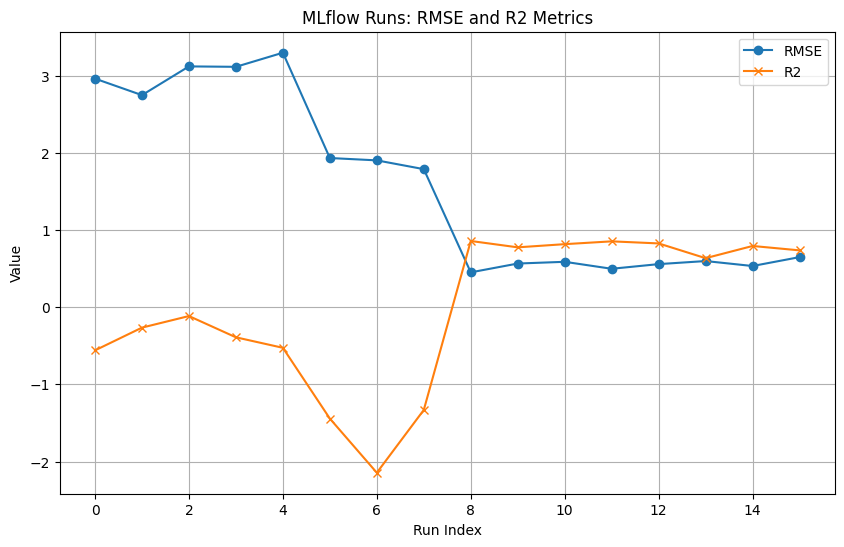

In [31]:
import matplotlib.pyplot as plt

runs = mlflow.search_runs(experiment_names=[EXPERIMENTO])
display(runs[["run_id","metrics.rmse","metrics.mae","metrics.r2","metrics.drift_psi_max","metrics.error_budget_pct"]])
runs.to_csv('mlflow.csv', index=False)
print('El archivo mlflow.csv ha sido guardado.')

# Generar un gráfico de las métricas RMSE y R2 por cada run
plt.figure(figsize=(10, 6))
plt.plot(runs.index, runs['metrics.rmse'], marker='o', label='RMSE')
plt.plot(runs.index, runs['metrics.r2'], marker='x', label='R2')
plt.xlabel('Run Index')
plt.ylabel('Value')
plt.title('MLflow Runs: RMSE and R2 Metrics')
plt.legend()
plt.grid(True)
plt.show()

**MLFOW DESPLIEGUE**

In [30]:
# ============================================
# MLFLOW CON NGROK - VERSIÓN CORREGIDA
# ============================================

print("="*60)
print("🚀 MLFLOW CON NGROK")
print("="*60)

# 1. Instalar dependencias
print("\n📦 Instalando dependencias...")
!pip install mlflow pyngrok -q

# 2. Importar
import mlflow
import time
import os
from pyngrok import ngrok, conf
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 3. Configurar ngrok con token
print("\n🔑 Configurando ngrok...")
print("👉 Ve a https://dashboard.ngrok.com/get-started/your-authtoken")
NGROK_AUTH_TOKEN = input("📝 Pega tu token de ngrok: ")
conf.get_default().auth_token = NGROK_AUTH_TOKEN
print("✅ Token configurado correctamente")

# 4. Configurar MLflow
print("\n🔧 Configurando MLflow...")
os.makedirs('mlruns', exist_ok=True)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("california_housing_monitoring")

# ⭐⭐⭐⭐⭐⭐ 5. INICIAR SERVIDOR CON --HOST 0.0.0.0  ⭐⭐⭐⭐⭐⭐
# ☝️ ESTA ES LA LÍNEA QUE DEBES MODIFICAR ☝️
print("\n🚀 Iniciando servidor MLflow con host 0.0.0.0...")
!fuser -k 5000/tcp 2>/dev/null  # mata cualquier proceso previo en el puerto 5000
time.sleep(2)
get_ipython().system_raw(
    "mlflow ui --backend-store-uri sqlite:///mlflow.db --host 0.0.0.0 --port 5000 --allowed-hosts '*' &"
)
time.sleep(5)
public_url = ngrok.connect(5000).public_url
print("MLflow UI:", public_url)

# 6. Crear túnel ngrok
print("\n🔗 Creando túnel ngrok...")
ngrok.kill()
time.sleep(2)
public_url = ngrok.connect(5000).public_url
print(f"\n✅ ¡MLflow UI disponible en:")
print(f"   🔗 {public_url}")

# 7. Cargar datos
print("\n📊 Cargando datos...")
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='MedHouseVal')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Datos cargados: {X.shape[0]} muestras, {X.shape[1]} features")

# 8. Entrenar y registrar en MLflow
print("\n🤖 Entrenando modelo y registrando en MLflow...")

with mlflow.start_run(run_name="random_forest_v1"):
    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("test_size", 0.3)
    mlflow.log_param("random_state", 42)

    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    model.fit(X_train_scaled, y_train)

    y_test_pred = model.predict(X_test_scaled)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, name="random_forest_model")

    print(f"✅ Modelo registrado - RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")

# 9. Verificar runs
print("\n🔍 Verificando experimentos registrados...")
runs = mlflow.search_runs()
print(f"   Total de ejecuciones registradas: {len(runs)}")

print("\n" + "="*60)
print("🎯 ¡MLflow LISTO!")
print(f"   📊 Dashboard: {public_url}")
print("   📸 Abre el enlace y toma captura de pantalla")
print("="*60)

🚀 MLFLOW CON NGROK

📦 Instalando dependencias...

🔑 Configurando ngrok...
👉 Ve a https://dashboard.ngrok.com/get-started/your-authtoken
📝 Pega tu token de ngrok: 3GkX31VenoVKJA9I4FLz0k31S46_3Q4J82MrAPbvHpdrTFRpT
✅ Token configurado correctamente

🔧 Configurando MLflow...

🚀 Iniciando servidor MLflow con host 0.0.0.0...
 35576 35579 35580 35581 35582MLflow UI: https://citric-victory-june.ngrok-free.dev

🔗 Creando túnel ngrok...

✅ ¡MLflow UI disponible en:
   🔗 https://citric-victory-june.ngrok-free.dev

📊 Cargando datos...
✅ Datos cargados: 20640 muestras, 8 features

🤖 Entrenando modelo y registrando en MLflow...
✅ Modelo registrado - RMSE: 0.5427, R²: 0.7756

🔍 Verificando experimentos registrados...
   Total de ejecuciones registradas: 8

🎯 ¡MLflow LISTO!
   📊 Dashboard: https://citric-victory-june.ngrok-free.dev
   📸 Abre el enlace y toma captura de pantalla
